# Data Overview

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim\data/raw/Synthetic_Financial_datasets_log.csv")
data.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\admin\AppData\Local\Temp\ipykernel_24788\3529440422.py:1: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv("D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim\data/raw/Synthetic_Financial_datasets_log.csv")


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
data.shape

(6362620, 11)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Insight 1: Sự lãng phí của kiểu dữ liệu mặc định (isFraud)
Mặc định, Pandas dùng int64 (8 bytes) cho cột isFraud. Nhưng chúng ta biết nó chỉ chứa 0 và 1.

Cách kiểm chứng:
Chúng ta sẽ so sánh dung lượng của cột này trước và sau khi ép về int8 (1 byte).

In [6]:
#1. Tính dung lượng hiện tại (đơn vị: Bytes)
original_size = data['isFraud'].memory_usage(index=False, deep=True)

In [7]:
# 2. Ép kiểu thử nghiệm
downcasted_isFraud = data['isFraud'].astype('int8')
new_size = downcasted_isFraud.memory_usage(index=False, deep=True)

In [8]:
print(f"Dung lượng ban đầu: {original_size/ 1024**2:.2f} MB")
print(f"Dung lượng sau khi tối ưu: {new_size / 1024**2:.2f} MB")
print(f"Tỷ lệ tiết kiệm: {(1- new_size/original_size)*100:.1f}%")

Dung lượng ban đầu: 48.54 MB
Dung lượng sau khi tối ưu: 6.07 MB
Tỷ lệ tiết kiệm: 87.5%


Insight 2: Tối ưu dựa trên dải giá trị thực tế (step)
Cột step đại diện cho số giờ. Trong dữ liệu đầy đủ, nó chỉ tới 743.

Cách kiểm chứng:
Chúng ta kiểm tra giá trị lớn nhất và xem nó có "vừa" với các kiểu dữ liệu nhỏ hơn không.

In [9]:
step_max = data['step'].max()
print(f"Giá trị lớn nhât của step: {step_max} ")

Giá trị lớn nhât của step: 743 


In [10]:
# Kiểm tra giới hạn của int16
import numpy as np
print(f"Giới hạn tối đa của int16: {np.iinfo(np.int16).max}")

Giới hạn tối đa của int16: 32767


Insight 3: Sai số khi dùng float32 cho giao dịch (amount)
Chúng ta sẽ xem liệu việc giảm độ chính xác có làm thay đổi số tiền đáng kể không.

Cách kiểm chứng:
Tính sự chênh lệch (sai số) giữa giá trị 64-bit và 32-bit.

In [11]:
# Tính sai số trung bình 
diff = (data['amount'] - data['amount'].astype('float32')).abs()
print(f"Sai số trung bình trên mỗi giao dịch: {diff.mean():.10f}")

Sai số trung bình trên mỗi giao dịch: 0.0037480100


In [13]:
import sys
sys.path.append('../')
from src.data_loader import load_paysim_data
df = load_paysim_data('D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim/data/raw/Synthetic_Financial_datasets_log.csv')
df.info()

--- Đang tải dữ liệu từ: D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim/data/raw/Synthetic_Financial_datasets_log.csv ---
Bộ nhớ tiêu thụ ban đầu: 533.97 MB
Bộ nhớ tiêu thụ sau tối ưu: 248.78 MB
Tiết kiệm được: 53.4%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int16   
 1   type            category
 2   amount          float32 
 3   nameOrig        object  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        object  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float32(5), int16(1), int8(2), object(2)
memory usage: 248.8+ MB


Phân loại biến

| Tên cột          | Nhóm biến          | Loại dữ liệu phân tích           | Ý nghĩa                                   |
| ---------------- | ------------------ | -------------------------------- | ----------------------------------------- |
| `step`           | Thời gian          | Numerical (Discrete / Time-like) | Đơn vị thời gian mô phỏng giao dịch       |
| `type`           | Mô tả giao dịch    | Categorical                      | Loại giao dịch                            |
| `amount`         | Mô tả giao dịch    | Numerical (Continuous)           | Giá trị giao dịch                         |
| `nameOrig`       | Định danh thực thể | Identifier                       | Mã tài khoản / người gửi                  |
| `oldbalanceOrg`  | Số dư tài khoản    | Numerical (Continuous)           | Số dư trước giao dịch của tài khoản nguồn |
| `newbalanceOrig` | Số dư tài khoản    | Numerical (Continuous)           | Số dư sau giao dịch của tài khoản nguồn   |
| `nameDest`       | Định danh thực thể | Identifier                       | Mã tài khoản / người nhận                 |
| `oldbalanceDest` | Số dư tài khoản    | Numerical (Continuous)           | Số dư trước giao dịch của tài khoản đích  |
| `newbalanceDest` | Số dư tài khoản    | Numerical (Continuous)           | Số dư sau giao dịch của tài khoản đích    |
| `isFraud`        | Nhãn / mục tiêu    | Binary / Target                  | Biến mục tiêu xác định giao dịch gian lận |
| `isFlaggedFraud` | Nhãn / cảnh báo    | Binary Indicator                 | Cờ cảnh báo gian lận do hệ thống gắn      |


# Kiểm tra chất lượng dữ liệu

In [14]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

# Phân tích đơn biến

## Nhóm thời gian

Cột step

In [25]:
print(data['step'].describe().apply(lambda x: format(x, 'f')))

count    6362620.000000
mean         243.397246
std          142.331971
min            1.000000
25%          156.000000
50%          239.000000
75%          335.000000
max          743.000000
Name: step, dtype: object


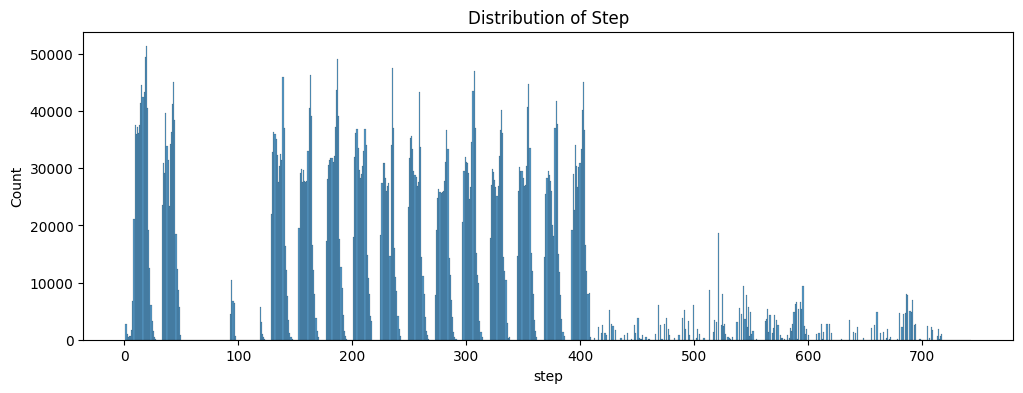

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
sns.histplot(data['step'], bins=743)
plt.title('Distribution of Step')
plt.show()

Từ biểu đồ ta thấy

1.Tính chu kỳ: Dữ liệu không dàn đều mà tạo thành các cụm giao dịch cao điểm, đan xen là những khoảng trũng rất sâu, nơi lượng giao dịch tụt xuống mức cực thấp.

2.Sự sụt giảm cấu trúc: Nửa đầu của biểu đồ (từ step 0 đến khoảng step 400) diễn ra vô cùng sôi động với hàng trăm ngàn giao dịch mỗi giờ. Tuy nhiên, kể từ sau khoảng step 400 (tương đương ngày thứ 16), lượng giao dịch sụt giảm một cách đột ngột và chỉ duy trì ở mức lác đác cho đến hết tháng.

Những "khoảng trũng" lặp đi lặp lại một cách đều đặn giữa các cụm giao dịch cao điểm kia đang phản ánh thực tế hành vi nào của người dùng? --> tính chu kỳ

Cụ thể hơn, những khoảng trũng sâu lặp đi lặp lại đó phản ánh chu kỳ sinh học bình thường của con người (Day/Night cycle). Đó chính là khoảng thời gian ban đêm (thường từ 1h đến 5h sáng), khi hầu hết người dùng đang ngủ và các hoạt động kinh tế cá nhân tạm dừng.

--> Nhóm giao dịch bình thường (chiếm đại đa số dữ liệu) bắt buộc phải tuân theo chu kỳ sinh hoạt này. Khối lượng giao dịch sẽ từ từ tăng lên vào buổi sáng, đạt đỉnh vào ban ngày và hạ nhiệt vào ban đêm.

Bây giờ, chúng ta dùng chính chu kỳ này làm "cái bẫy" để nhận diện kẻ gian. Hãy tưởng tượng về cách thức hoạt động của tội phạm mạng: chúng có thể sử dụng các tập lệnh tự động (botnet) để liên tục vét tiền từ tài khoản nạn nhân, hoặc chúng là những hacker đang ngồi ở một quốc gia khác, với một múi giờ hoàn toàn khác.

Nếu tách riêng các vụ Gian lận (isFraud = 1) ra và vẽ lên biểu đồ 24 giờ, phân phối của nhóm gian lận có bị "trũng xuống" vào ban đêm giống như người bình thường không? --> hour + isFraud 

## Nhóm mô tả giao dịch


Cột type

Cột amount

## Nhóm định danh


Cột nameOrig

Cột nameDest

## Nhóm số dư

Cột oldbalanceOrg

Cột newbalanceOrig

Cột oldbalanceDest

Cột newbalanceDest

## Nhóm nhãn

Cột isFraud

Cột IsFlaggedFraud

## Phân tích đa biến